In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
plt.rc('font', family='Malgun Gothic')

In [2]:
# _PROJECT_ROOT = Path(__file__).resolve().parent.parent.parent
# _DEFAULT_JSON_PATH = _PROJECT_ROOT / "data.json"
_DEFAULT_JSON_PATH =  "./data.json"


def load_data(json_path=None):
    if json_path is None:
        json_path = _DEFAULT_JSON_PATH
    json_path = Path(json_path)

    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    records = []
    for sido, districts in data.items():
        for sigungu, metrics in districts.items():
            record = { 
                'sido': sido,
                'sigungu': sigungu,
                **metrics  # 중첩 데이터 flat
            }
            records.append(record)

    df = pd.json_normalize(records)

    # df 열
    cols = ['sido', 'sigungu', 'population', 'crime', 'violence',
                    'burgerking', 'lotteria', 'mcdonalds', 'kfc']
    df = df[cols]

    # 범죄율
    df['crime_rate'] = (df['crime'] + df['violence'])/ df['population']
    # 버거지수
    df['burger_ind'] = (df['burgerking'] + df['lotteria'] + df['mcdonalds'] + df['kfc']) / df['lotteria']
    df['burger_ind'] = df.apply(lambda row: 0 if row['lotteria'] == 0 else row['burger_ind'], axis=1)
    return df


df = load_data()
df.head()

,sido,sigungu,population,crime,violence,burgerking,lotteria,mcdonalds,kfc,crime_rate,burger_ind
0,서울,강남구,557345,17235,4012,9,7,9,8,0.038122,4.714286
1,서울,강동구,476942,5328,1697,4,8,3,3,0.014729,2.250000
2,서울,강북구,283597,4264,1320,3,5,4,2,0.019690,2.800000
3,서울,강서구,556171,7727,2337,7,12,4,4,0.018095,2.250000
4,서울,관악구,477812,8651,2520,6,9,1,3,0.023379,2.111111


C:\Users\Playdata\AppData\Local\Temp\ipykernel_13960\818275157.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('crime_rate_bin')['burger_ind'].mean()


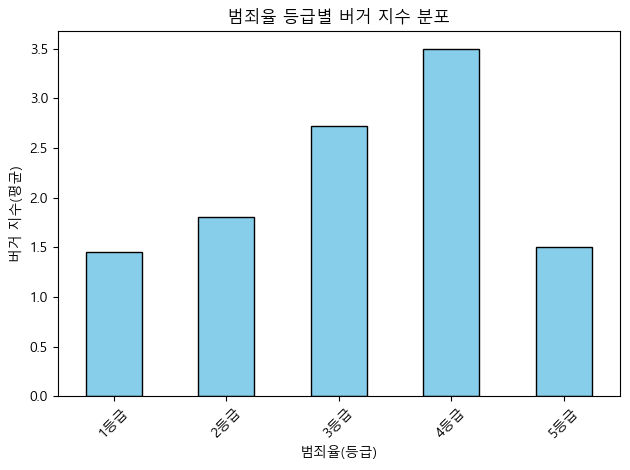

In [3]:


# crime rate 를 구간으로 나누고 각 구간별로 burger ind 의 평균을 그래프로

# crime_rate를 5개 구간으로 나누기
labels = ['1등급', '2등급', '3등급', '4등급', '5등급']
df['crime_rate_bin'] = pd.cut(df['crime_rate'], bins=5, labels=labels)

# 각 구간별 burger_ind 평균 계산
grouped = df.groupby('crime_rate_bin')['burger_ind'].mean()

# 히스토그램 그리기
grouped.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel('범죄율(등급)')
plt.ylabel('버거 지수(평균)')
plt.title('범죄율 등급별 버거 지수 분포')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
